# Medical Insurance Cost Prediction — Regression Practice

**Data source**: [Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance) by mirichoi0218 on Kaggle.

Local file: `data/insurance.csv`

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
insurance_data = pd.read_csv("data/insurance.csv")
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
insurance_data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [4]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
insurance_data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
(insurance_data == 0).sum()

age           0
sex           0
bmi           0
children    574
smoker        0
region        0
charges       0
dtype: int64

In [7]:
import seaborn as sns
#simpler way to plot
import matplotlib.pyplot as plt

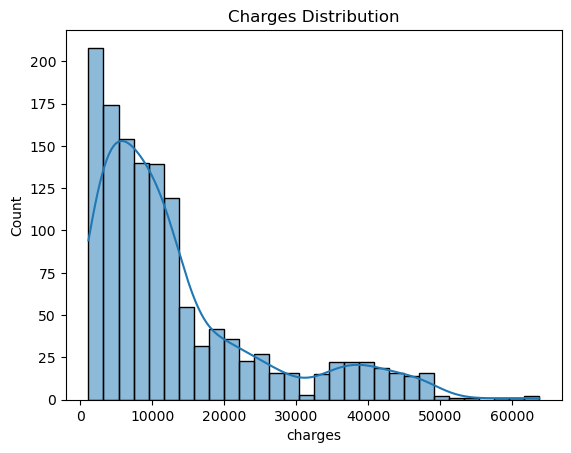

In [8]:
sns.histplot(
    data=insurance_data,
    x="charges",
    kde=True
)

plt.title("Charges Distribution")
plt.show()

<Axes: xlabel='smoker', ylabel='charges'>

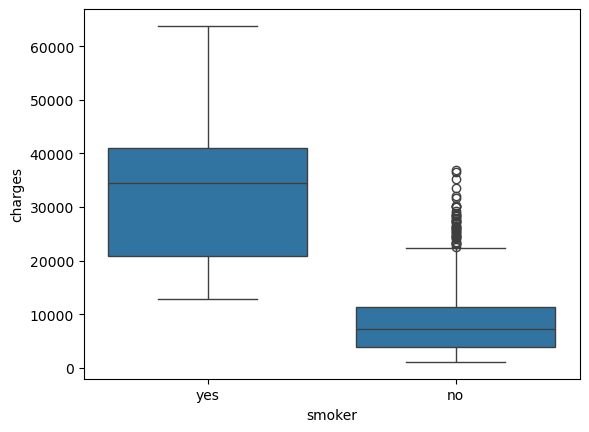

In [9]:
sns.boxplot(
        data=insurance_data,
        x="smoker",
        y="charges"
    )

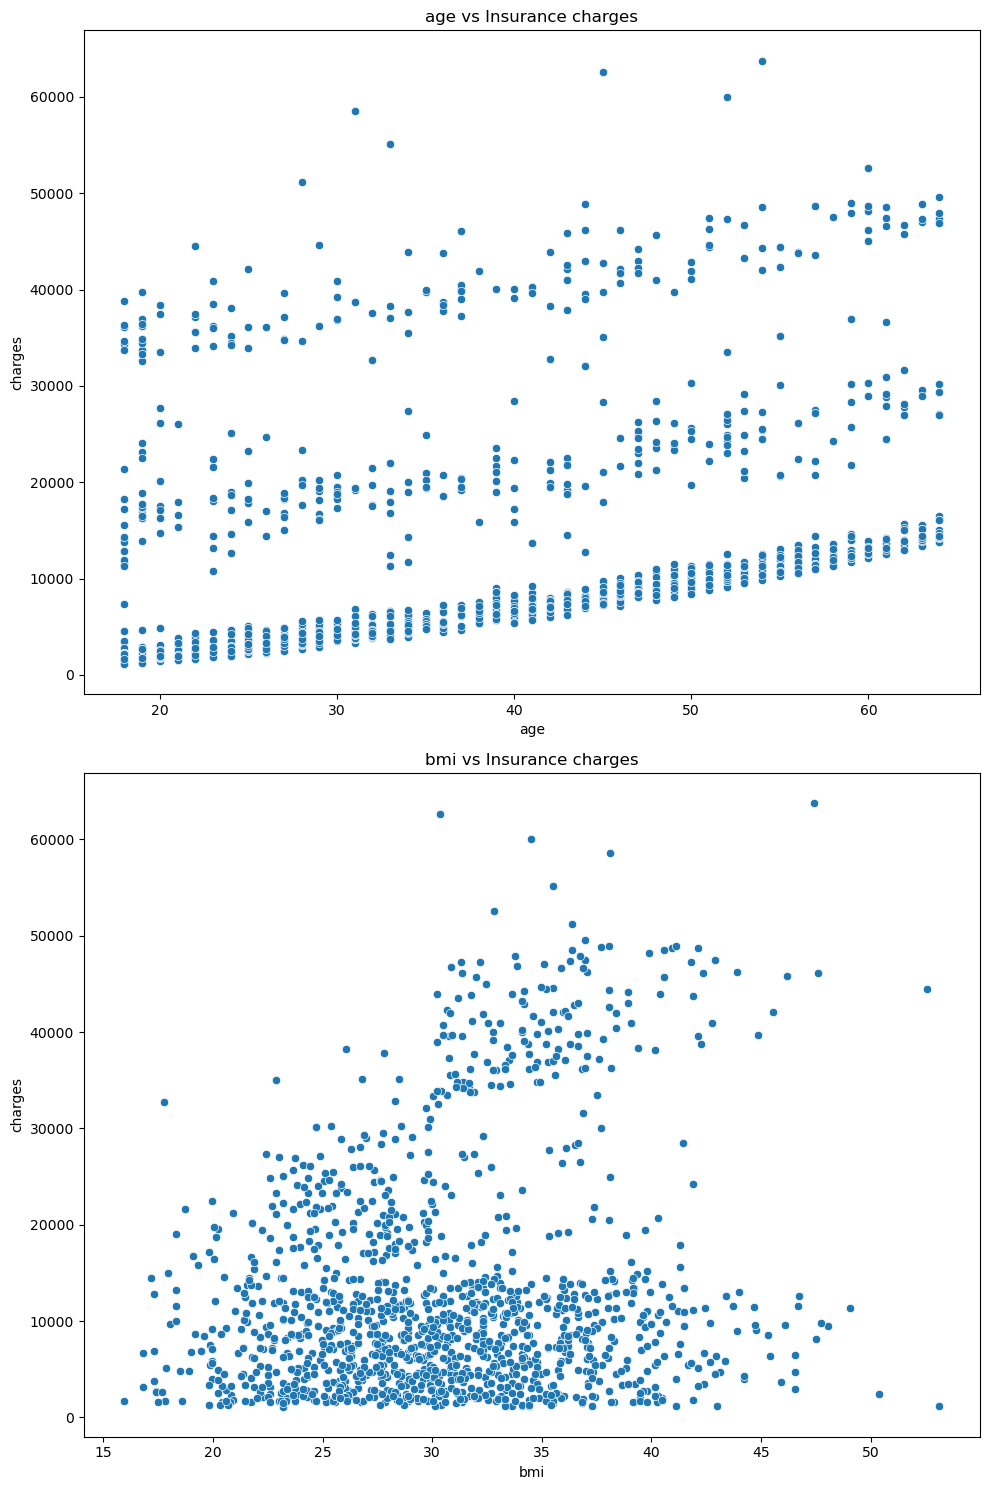

In [10]:
features = [
    "age",
    "bmi"
]

fig, axes = plt.subplots(
    2, 1,
    figsize= (10,15) 
)

axes = axes.flatten()

for ax, feature in zip(axes, features):

    sns.scatterplot(
        data=insurance_data,
        x=feature,
        y="charges",
        ax=ax
    )

    ax.set_title(f"{feature} vs Insurance charges")

plt.tight_layout()
plt.show()

<Axes: xlabel='bmi', ylabel='charges'>

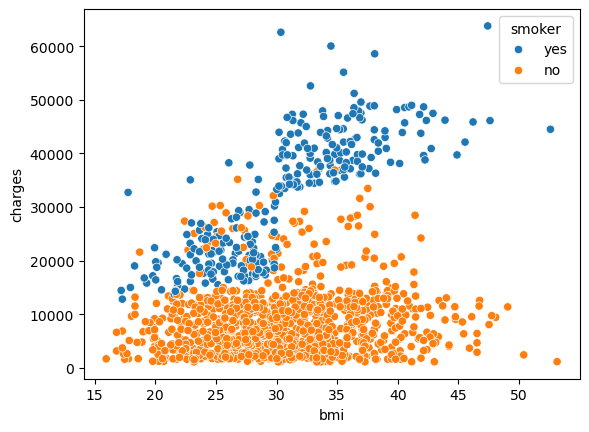

In [11]:
sns.scatterplot(
    data=insurance_data,
    x="bmi",
    y="charges",
    hue="smoker"
)

用 sns.scatterplot 画 bmi vs charges，加一个新参数 hue="smoker"，让点按抽烟与否自动分两种颜色:

One-hot coding

In [12]:
insurance_data_encoded = pd.get_dummies(
    insurance_data,
    columns=["sex", "smoker", "region"],
    drop_first=True
)

insurance_data_encoded["bmi_smoker"] = insurance_data_encoded["bmi"] * insurance_data_encoded["smoker_yes"]
insurance_data_encoded["obese"] = (insurance_data_encoded["bmi"] >= 30).astype(int)
insurance_data_encoded["obese_smoker"] = insurance_data_encoded["obese"] * insurance_data_encoded["smoker_yes"]

#add three more columns to reduce residual
"""通用判断标准就一句话：如果你能通过"这个点的预测值大概是多少"或者"这个点属于哪个子群体"，
大致猜出它的残差会偏高还是偏低，那说明模型还有信息没用上；如果完全猜不出规律，那才是干净的模型。"""

insurance_data_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_smoker,obese,obese_smoker
0,19,27.900,0,16884.92400,False,True,False,False,True,27.9,0,0
1,18,33.770,1,1725.55230,True,False,False,True,False,0.0,1,0
2,28,33.000,3,4449.46200,True,False,False,True,False,0.0,1,0
3,33,22.705,0,21984.47061,True,False,True,False,False,0.0,0,0
4,32,28.880,0,3866.85520,True,False,True,False,False,0.0,0,0


这里 drop_first=True 是个容易被忽略但很重要的参数——如果不加，sex 会同时生成 sex_male 和 sex_female 两列，但这两列其实包含了完全一样的信息（知道其中一列就能推出另一列，一个是 1 另一个必然是 0）。回忆一下你在上个项目学过的共线性——两个高度相关（这里是完全相关）的列同时存在会干扰模型解读系数，drop_first=True 就是把这种冗余信息直接砍掉，只保留 sex_male 一列就够了（0 就代表 female）。

In [13]:
X = insurance_data_encoded.drop(columns="charges")
Y = insurance_data_encoded["charges"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

model = LinearRegression()
model.fit(X_train, Y_train)
print(X.shape, X_train.shape, X_test.shape)

(1338, 11) (1070, 11) (268, 11)


In [14]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

Y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred)
rmse = root_mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MSE: 19086246.799478866
RMSE: 4368.780928300121
R2: 0.8729115062850308


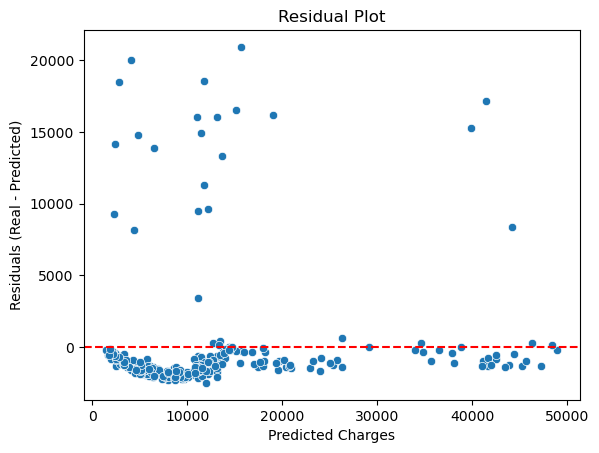

In [15]:
residuals = Y_test - Y_pred

sns.scatterplot(x=Y_pred, y=residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals (Real - Predicted)")
plt.title("Residual Plot")
plt.show()

It's not about smoking and obese group, cuz there are people on upper left corner.
Perheaps is because higher BMI can lead to much higher chargers. Retry below

In [16]:
insurance_data_encoded["bmi_squared"] = insurance_data_encoded["bmi"] ** 2

In [17]:
X_v2 = insurance_data_encoded.drop(columns="charges")
X_train_v2, X_test_v2, Y_train, Y_test = train_test_split(X_v2, Y, test_size=0.2, random_state=2)

model_v2 = LinearRegression()
model_v2.fit(X_train_v2, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
Y_pred_v2 = model_v2.predict(X_test_v2)

mse_v2 = mean_squared_error(Y_test, Y_pred_v2)
rmse_v2 = root_mean_squared_error(Y_test, Y_pred_v2)
r2_v2 = r2_score(Y_test, Y_pred_v2)

print("MSE:", mse_v2)
print("RMSE:", rmse_v2)
print("R2:", r2_v2)

MSE: 19009667.276524402
RMSE: 4360.007715190926
R2: 0.8734214219496421


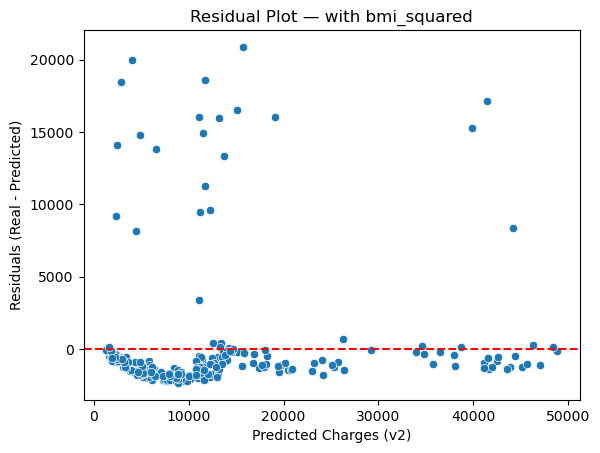

In [19]:
residuals_v2 = Y_test - Y_pred_v2

sns.scatterplot(x=Y_pred_v2, y=residuals_v2)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Charges (v2)")
plt.ylabel("Residuals (Real - Predicted)")
plt.title("Residual Plot — with bmi_squared")
plt.show()

## Project Summary

**Goal**: Predict medical insurance `charges` (a continuous value) — the first regression project, done as a follow-up to the earlier classification project (diabetes prediction) to compare the two problem types.

**Data**: 1,338 rows, 7 columns, no missing values. Checked all numeric columns for zeros; only `children` had any (a valid value — no kids), so there was no "zero disguised as missing data" here, and the cleaning step was skipped.

**EDA findings**:
- `charges` is right-skewed — most people have low costs, with a small number of extreme high-cost outliers pulling a long tail
- `smoker` has a huge effect on `charges` — the two groups barely overlap on the boxplot
- `bmi` alone has a loose relationship with `charges`, but coloring the scatterplot by `smoker` revealed a clear **interaction effect**: for non-smokers, higher BMI barely raises cost; for smokers, cost rises sharply as BMI increases

**Feature engineering**: One-hot encoded `sex`/`smoker`/`region` with `pd.get_dummies(drop_first=True)`. Based on the interaction found during EDA, manually engineered `bmi_smoker` (a continuous interaction term), `obese`/`obese_smoker` (a BMI≥30 threshold flag), and `bmi_squared` (to capture the non-linear, accelerating effect of BMI).

**Modeling iterations**:

| Version | Features | RMSE | R² |
|---|---|---|---|
| Baseline | One-hot encoded raw fields, no interaction terms | $6,189 | 0.745 |
| v1 | + `bmi_smoker` + `obese` + `obese_smoker` | $4,369 | 0.873 |
| v2 (final) | + `bmi_squared` | **$4,360** | **0.873** |

The jump from baseline to v1 came mainly from explicitly feeding the model the "smoker × BMI" interaction discovered during EDA — a plain linear regression assumes each feature acts independently, so without this step the model couldn't learn that BMI's effect depends on smoking status just from the separate `bmi` and `smoker_yes` coefficients. `bmi_squared` added only a marginal gain on top of that, suggesting most of the non-linear signal was already captured by the earlier interaction terms.

**Residual diagnostics and limitations**: The residual plot consistently showed a cluster of about 21 outlier points that neither the smoker interaction term, the obesity threshold feature, nor the BMI-squared term could shrink. Investigating this cluster directly showed its `smoker` rate, `age` distribution, and `children` distribution were all in line with the overall test set — meaning **the 6 available raw fields simply can't explain why these particular people's costs are so much higher than predicted**. This is most likely driven by information the dataset doesn't capture (medical history, occupational risk, etc.) or inherent noise in how the dataset was generated, rather than something more feature engineering could fix — so further blind feature guessing was deliberately stopped here to avoid p-hacking.

**Conclusion**: An R² of 0.873 is a solid result for a linear regression model built on only 6 raw fields with no additional medical history. The model's limitation is documented honestly rather than hidden: a small subset of samples has unusually high costs that the available features cannot explain.